# Persistence-Adjusted Delta and Log-Ratio Checks

This companion checkpoint treats the level-target persistence result as a research finding, then asks whether public predictors explain within-country movement in environment-related innovation.

The notebook is a driver and artifact viewer only. Modeling logic lives in `3_models/scripts/persistence_adjusted_modeling.py`.

## Protocol Contract

- Main supplemental target: `delta_lag1`, the annual change from the same country's previous calendar-year target value.
- Robustness target: `log_ratio_lag1`, the true log ratio relative to the same country's previous calendar-year target value.
- Panels: active v2 `main`, `suba`, `subb`, and `subc` no-imputation panels.
- Predictor timing: both `lag1_3_mean` and `lag1`.
- Model families compared separately: Linear, RandomForest, and XGBoost.
- Split rule: chronological 80/10/10 train/validation/test inside each adjusted panel.
- Baseline: zero-change on the adjusted target. Negative `delta_test_mae_vs_zero_change` means the model improves on the zero-change baseline.

## Optional Colab Setup

In [1]:
# Local runs skip this setup branch.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Clone or upload the repository, then set PROJECT_ROOT = Path("/content/env-innovation-prediction") before continuing.')
else:
    print('Local run detected; setup skipped.')

Local run detected; setup skipped.


## Run Script Pipeline

In [2]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

_project_root_override = globals().get('PROJECT_ROOT')
if _project_root_override is not None:
    PROJECT_ROOT = Path(_project_root_override).resolve()
else:
    PROJECT_ROOT = Path.cwd().resolve()
    while PROJECT_ROOT.name != 'env-innovation-prediction' and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / '3_models' / 'scripts').exists():
    raise RuntimeError(f'Could not find project root from {Path.cwd()}')

scripts_dir = PROJECT_ROOT / '3_models' / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from persistence_adjusted_modeling import (
    PERSISTENCE_FIGURE_OUTPUT,
    PERSISTENCE_IMPORTANCE_FIGURE_OUTPUT,
    PERSISTENCE_IMPORTANCE_OUTPUT,
    PERSISTENCE_OUTPUT,
    PERSISTENCE_RUN_SUMMARY_OUTPUT,
    PERSISTENCE_SUMMARY_OUTPUT,
    PERSISTENCE_TOP_IMPORTANCE_OUTPUT,
    run_and_write_outputs,
)

RUN_FULL = globals().get('RUN_FULL', False)
required_outputs = [
    PERSISTENCE_OUTPUT,
    PERSISTENCE_SUMMARY_OUTPUT,
    PERSISTENCE_RUN_SUMMARY_OUTPUT,
    PERSISTENCE_IMPORTANCE_OUTPUT,
    PERSISTENCE_TOP_IMPORTANCE_OUTPUT,
]

if RUN_FULL or not all(path.exists() for path in required_outputs):
    outputs = run_and_write_outputs(random_state=42)
    results = outputs['results']
    summary = outputs['summary']
    importance = outputs['importance']
    top_importance = outputs['top_importance']
else:
    results = pd.read_csv(PERSISTENCE_OUTPUT)
    summary = pd.read_csv(PERSISTENCE_SUMMARY_OUTPUT)
    importance = pd.read_csv(PERSISTENCE_IMPORTANCE_OUTPUT)
    top_importance = pd.read_csv(PERSISTENCE_TOP_IMPORTANCE_OUTPUT)
print(f'Available: {PERSISTENCE_OUTPUT}')
print(f'Available: {PERSISTENCE_SUMMARY_OUTPUT}')
print(f'Available: {PERSISTENCE_RUN_SUMMARY_OUTPUT}')
print(f'Available: {PERSISTENCE_IMPORTANCE_OUTPUT}')
print(f'Available: {PERSISTENCE_TOP_IMPORTANCE_OUTPUT}')

Available: /Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction/3_models/outputs/persistence_adjusted_model_family_comparison.csv
Available: /Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction/3_models/outputs/persistence_adjusted_model_family_summary.csv
Available: /Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction/3_models/outputs/persistence_adjusted_run_summary.md
Available: /Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction/3_models/outputs/persistence_adjusted_native_importance.csv
Available: /Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction/3_models/outputs/persistence_adjusted_top_interpretation_features.csv


## Run Summary

In [3]:
display(Markdown(PERSISTENCE_RUN_SUMMARY_OUTPUT.read_text()))

# Persistence-Adjusted Target Run Summary

This run treats the original level-target persistence result as the first finding, then adds a supplemental target task.

Target variants:

- `delta_lag1` (main_supplement): Annual change from the same country's previous calendar-year target value.
- `log_ratio_lag1` (robustness): Log ratio relative to the same country's previous calendar-year target value.

All rows use the same chronological 80/10/10 split rule within each adjusted panel.
The baseline is a zero-change baseline on the adjusted target, equivalent to predicting no movement from the previous calendar-year target value.

## Validation-Selected Family Per Panel And Lag

| target_variant   | target_role     | panel_id   | panel_label                            | lag_suffix   | family       | best_model                   |   validation_mae |   test_mae |   test_minus_validation_mae |   zero_change_baseline_mae |   delta_test_mae_vs_zero_change | beats_zero_change_baseline   |   test_spearman |   n_test |   dropped_non_annual_pairs |   dropped_nonpositive_pairs |
|:-----------------|:----------------|:-----------|:---------------------------------------|:-------------|:-------------|:-----------------------------|-----------------:|-----------:|----------------------------:|---------------------------:|--------------------------------:|:-----------------------------|----------------:|---------:|---------------------------:|----------------------------:|
| delta_lag1       | main_supplement | main       | Main v2 model                          | lag1         | RandomForest | rf_n200_d10                  |        0.0898502 |   0.179284 |                   0.0894335 |                   0.183521 |                    -0.0042371   | True                         |      0.141757   |      269 |                        264 |                           0 |
| delta_lag1       | main_supplement | main       | Main v2 model                          | lag1_3_mean  | RandomForest | rf_n100                      |        0.0854506 |   0.171305 |                   0.0858543 |                   0.183521 |                    -0.0122159   | True                         |      0.062579   |      269 |                        264 |                           0 |
| delta_lag1       | main_supplement | suba       | Submodel A: RISE and high-tech exports | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.239123  |   0.176719 |                  -0.0624037 |                   0.166913 |                     0.0098058   | False                        |      0.00314425 |       76 |                         77 |                           0 |
| delta_lag1       | main_supplement | suba       | Submodel A: RISE and high-tech exports | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.238831  |   0.180493 |                  -0.0583377 |                   0.166913 |                     0.0135796   | False                        |      0.00467532 |       76 |                         77 |                           0 |
| delta_lag1       | main_supplement | subb       | Submodel B: R&D, co-invention, and tax | lag1         | RandomForest | rf_n500_d10                  |        0.0992375 |   0.17556  |                   0.0763224 |                   0.194385 |                    -0.0188246   | True                         |      0.103564   |      258 |                        138 |                           0 |
| delta_lag1       | main_supplement | subb       | Submodel B: R&D, co-invention, and tax | lag1_3_mean  | RandomForest | rf_n200_d10                  |        0.0884502 |   0.161525 |                   0.0730749 |                   0.194385 |                    -0.0328594   | True                         |      0.171111   |      258 |                        138 |                           0 |
| delta_lag1       | main_supplement | subc       | Submodel C: OECD EPS                   | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.184344  |   0.26674  |                   0.0823963 |                   0.266791 |                    -5.13169e-05 | True                         |     -0.0114146  |      160 |                          3 |                           0 |
| delta_lag1       | main_supplement | subc       | Submodel C: OECD EPS                   | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.184344  |   0.26674  |                   0.0823963 |                   0.266791 |                    -5.13169e-05 | True                         |     -0.0401712  |      160 |                          3 |                           0 |
| log_ratio_lag1   | robustness      | main       | Main v2 model                          | lag1         | RandomForest | rf_n100_d10                  |        0.36016   |   0.443029 |                   0.082869  |                   0.44643  |                    -0.00340109  | True                         |      0.377667   |      269 |                        264 |                           0 |
| log_ratio_lag1   | robustness      | main       | Main v2 model                          | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.8 |        0.419043  |   0.446055 |                   0.0270114 |                   0.44643  |                    -0.000375136 | True                         |      0.11397    |      269 |                        264 |                           0 |
| log_ratio_lag1   | robustness      | suba       | Submodel A: RISE and high-tech exports | lag1         | RandomForest | rf_n100_d10                  |        0.450157  |   0.492449 |                   0.0422927 |                   0.439276 |                     0.0531729   | False                        |     -0.46569    |       76 |                         77 |                           0 |
| log_ratio_lag1   | robustness      | suba       | Submodel A: RISE and high-tech exports | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.2 |        0.452944  |   0.442847 |                  -0.0100969 |                   0.439276 |                     0.00357086  | False                        |     -0.224978   |       76 |                         77 |                           0 |
| log_ratio_lag1   | robustness      | subb       | Submodel B: R&D, co-invention, and tax | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.3898    |   0.430103 |                   0.0403031 |                   0.428976 |                     0.00112638  | False                        |      0.0342879  |      258 |                        138 |                           0 |
| log_ratio_lag1   | robustness      | subb       | Submodel B: R&D, co-invention, and tax | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.3898    |   0.430103 |                   0.0403031 |                   0.428976 |                     0.00112638  | False                        |     -0.040791   |      258 |                        138 |                           0 |
| log_ratio_lag1   | robustness      | subc       | Submodel C: OECD EPS                   | lag1         | Linear       | linear_regression            |        0.148358  |   0.175647 |                   0.0272891 |                   0.174531 |                     0.00111622  | False                        |     -0.0443085  |      160 |                          3 |                           0 |
| log_ratio_lag1   | robustness      | subc       | Submodel C: OECD EPS                   | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.146305  |   0.178507 |                   0.0322019 |                   0.174531 |                     0.00397592  | False                        |     -0.104848   |      160 |                          3 |                           0 |

## Full Family Comparison

| target_variant   | panel_id   | lag_suffix   | family       | best_model                   |   validation_mae |   test_mae |   test_minus_validation_mae |   zero_change_baseline_mae |   delta_test_mae_vs_zero_change | beats_zero_change_baseline   |   n_test |   dropped_non_annual_pairs |   dropped_nonpositive_pairs |
|:-----------------|:-----------|:-------------|:-------------|:-----------------------------|-----------------:|-----------:|----------------------------:|---------------------------:|--------------------------------:|:-----------------------------|---------:|---------------------------:|----------------------------:|
| delta_lag1       | main       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.2 |        0.106043  |   0.183388 |                  0.0773452  |                   0.183521 |                    -0.000132367 | True                         |      269 |                        264 |                           0 |
| delta_lag1       | main       | lag1_3_mean  | RandomForest | rf_n100                      |        0.0854506 |   0.171305 |                  0.0858543  |                   0.183521 |                    -0.0122159   | True                         |      269 |                        264 |                           0 |
| delta_lag1       | main       | lag1_3_mean  | XGBoost      | xgb_n100_d6                  |        0.0889573 |   0.181152 |                  0.0921952  |                   0.183521 |                    -0.00236841  | True                         |      269 |                        264 |                           0 |
| delta_lag1       | main       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.2 |        0.106043  |   0.183678 |                  0.0776351  |                   0.183521 |                     0.000157597 | False                        |      269 |                        264 |                           0 |
| delta_lag1       | main       | lag1         | RandomForest | rf_n200_d10                  |        0.0898502 |   0.179284 |                  0.0894335  |                   0.183521 |                    -0.0042371   | True                         |      269 |                        264 |                           0 |
| delta_lag1       | main       | lag1         | XGBoost      | xgb_n100_d3                  |        0.091052  |   0.179432 |                  0.0883803  |                   0.183521 |                    -0.00408847  | True                         |      269 |                        264 |                           0 |
| delta_lag1       | suba       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.238831  |   0.180493 |                 -0.0583377  |                   0.166913 |                     0.0135796   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | suba       | lag1_3_mean  | RandomForest | rf_n500_d10                  |        0.244346  |   0.256532 |                  0.0121867  |                   0.166913 |                     0.0896189   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | suba       | lag1_3_mean  | XGBoost      | xgb_n100_d6                  |        0.271697  |   0.239462 |                 -0.032235   |                   0.166913 |                     0.0725484   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | suba       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.239123  |   0.176719 |                 -0.0624037  |                   0.166913 |                     0.0098058   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | suba       | lag1         | RandomForest | rf_n100                      |        0.260475  |   0.243357 |                 -0.0171179  |                   0.166913 |                     0.0764434   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | suba       | lag1         | XGBoost      | xgb_n100_d6                  |        0.256065  |   0.219654 |                 -0.0364117  |                   0.166913 |                     0.0527404   | False                        |       76 |                         77 |                           0 |
| delta_lag1       | subb       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.113153  |   0.19437  |                  0.0812165  |                   0.194385 |                    -1.47045e-05 | True                         |      258 |                        138 |                           0 |
| delta_lag1       | subb       | lag1_3_mean  | RandomForest | rf_n200_d10                  |        0.0884502 |   0.161525 |                  0.0730749  |                   0.194385 |                    -0.0328594   | True                         |      258 |                        138 |                           0 |
| delta_lag1       | subb       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.110124  |   0.193741 |                  0.0836167  |                   0.194385 |                    -0.000643854 | True                         |      258 |                        138 |                           0 |
| delta_lag1       | subb       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.113153  |   0.19437  |                  0.0812165  |                   0.194385 |                    -1.47045e-05 | True                         |      258 |                        138 |                           0 |
| delta_lag1       | subb       | lag1         | RandomForest | rf_n500_d10                  |        0.0992375 |   0.17556  |                  0.0763224  |                   0.194385 |                    -0.0188246   | True                         |      258 |                        138 |                           0 |
| delta_lag1       | subb       | lag1         | XGBoost      | xgb_n100_d3                  |        0.115079  |   0.198769 |                  0.0836898  |                   0.194385 |                     0.00438479  | False                        |      258 |                        138 |                           0 |
| delta_lag1       | subc       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.184344  |   0.26674  |                  0.0823963  |                   0.266791 |                    -5.13169e-05 | True                         |      160 |                          3 |                           0 |
| delta_lag1       | subc       | lag1_3_mean  | RandomForest | rf_n500_d10                  |        0.248042  |   0.336255 |                  0.0882129  |                   0.266791 |                     0.0694639   | False                        |      160 |                          3 |                           0 |
| delta_lag1       | subc       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.250162  |   0.320317 |                  0.0701549  |                   0.266791 |                     0.0535252   | False                        |      160 |                          3 |                           0 |
| delta_lag1       | subc       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.184344  |   0.26674  |                  0.0823963  |                   0.266791 |                    -5.13169e-05 | True                         |      160 |                          3 |                           0 |
| delta_lag1       | subc       | lag1         | RandomForest | rf_n500_d10                  |        0.231058  |   0.33078  |                  0.0997223  |                   0.266791 |                     0.0639887   | False                        |      160 |                          3 |                           0 |
| delta_lag1       | subc       | lag1         | XGBoost      | xgb_n100_d3                  |        0.217511  |   0.313701 |                  0.0961896  |                   0.266791 |                     0.0469095   | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | main       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.8 |        0.419043  |   0.446055 |                  0.0270114  |                   0.44643  |                    -0.000375136 | True                         |      269 |                        264 |                           0 |
| log_ratio_lag1   | main       | lag1_3_mean  | RandomForest | rf_n100_d10                  |        0.421922  |   0.466434 |                  0.0445118  |                   0.44643  |                     0.0200043   | False                        |      269 |                        264 |                           0 |
| log_ratio_lag1   | main       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.427581  |   0.459472 |                  0.0318906  |                   0.44643  |                     0.0130422   | False                        |      269 |                        264 |                           0 |
| log_ratio_lag1   | main       | lag1         | Linear       | lasso_alpha_0.1              |        0.413283  |   0.446198 |                  0.0329145  |                   0.44643  |                    -0.000231857 | True                         |      269 |                        264 |                           0 |
| log_ratio_lag1   | main       | lag1         | RandomForest | rf_n100_d10                  |        0.36016   |   0.443029 |                  0.082869   |                   0.44643  |                    -0.00340109  | True                         |      269 |                        264 |                           0 |
| log_ratio_lag1   | main       | lag1         | XGBoost      | xgb_n100_d3                  |        0.374846  |   0.437382 |                  0.0625358  |                   0.44643  |                    -0.00904793  | True                         |      269 |                        264 |                           0 |
| log_ratio_lag1   | suba       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.2 |        0.452944  |   0.442847 |                 -0.0100969  |                   0.439276 |                     0.00357086  | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | suba       | lag1_3_mean  | RandomForest | rf_n100_d10                  |        0.469441  |   0.478271 |                  0.00883075 |                   0.439276 |                     0.038995    | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | suba       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.470218  |   0.487934 |                  0.0177158  |                   0.439276 |                     0.0486572   | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | suba       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.452944  |   0.442847 |                 -0.0100969  |                   0.439276 |                     0.00357086  | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | suba       | lag1         | RandomForest | rf_n100_d10                  |        0.450157  |   0.492449 |                  0.0422927  |                   0.439276 |                     0.0531729   | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | suba       | lag1         | XGBoost      | xgb_n100_d3                  |        0.477716  |   0.501541 |                  0.0238251  |                   0.439276 |                     0.0622643   | False                        |       76 |                         77 |                           0 |
| log_ratio_lag1   | subb       | lag1_3_mean  | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.3898    |   0.430103 |                  0.0403031  |                   0.428976 |                     0.00112638  | False                        |      258 |                        138 |                           0 |
| log_ratio_lag1   | subb       | lag1_3_mean  | RandomForest | rf_n200_d10                  |        0.396107  |   0.436758 |                  0.0406508  |                   0.428976 |                     0.00778174  | False                        |      258 |                        138 |                           0 |
| log_ratio_lag1   | subb       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.405238  |   0.426339 |                  0.0211015  |                   0.428976 |                    -0.00263707  | True                         |      258 |                        138 |                           0 |
| log_ratio_lag1   | subb       | lag1         | Linear       | elastic_net_alpha_0.1_l1_0.5 |        0.3898    |   0.430103 |                  0.0403031  |                   0.428976 |                     0.00112638  | False                        |      258 |                        138 |                           0 |
| log_ratio_lag1   | subb       | lag1         | RandomForest | rf_n100_d10                  |        0.397104  |   0.440392 |                  0.0432878  |                   0.428976 |                     0.0114156   | False                        |      258 |                        138 |                           0 |
| log_ratio_lag1   | subb       | lag1         | XGBoost      | xgb_n100_d3                  |        0.409689  |   0.434693 |                  0.0250036  |                   0.428976 |                     0.00571677  | False                        |      258 |                        138 |                           0 |
| log_ratio_lag1   | subc       | lag1_3_mean  | Linear       | linear_regression            |        0.148595  |   0.175724 |                  0.0271285  |                   0.174531 |                     0.00119231  | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | subc       | lag1_3_mean  | RandomForest | rf_n500_d10                  |        0.167099  |   0.186252 |                  0.0191532  |                   0.174531 |                     0.0117211   | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | subc       | lag1_3_mean  | XGBoost      | xgb_n100_d3                  |        0.146305  |   0.178507 |                  0.0322019  |                   0.174531 |                     0.00397592  | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | subc       | lag1         | Linear       | linear_regression            |        0.148358  |   0.175647 |                  0.0272891  |                   0.174531 |                     0.00111622  | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | subc       | lag1         | RandomForest | rf_n200_d10                  |        0.167742  |   0.192243 |                  0.0245006  |                   0.174531 |                     0.0177116   | False                        |      160 |                          3 |                           0 |
| log_ratio_lag1   | subc       | lag1         | XGBoost      | xgb_n100_d3                  |        0.163656  |   0.182199 |                  0.0185426  |                   0.174531 |                     0.00766759  | False                        |      160 |                          3 |                           0 |


## Main Supplemental Task: Delta Target

,panel_id,lag_suffix,family,best_model,validation_mae,test_mae,test_minus_validation_mae,zero_change_baseline_mae,delta_test_mae_vs_zero_change,beats_zero_change_baseline,n_test,dropped_non_annual_pairs
0,main,lag1_3_mean,Linear,elastic_net_alpha_0.1_l1_0.2,0.106043,0.183388,0.077345,0.183521,-0.000132,True,269,264
1,main,lag1_3_mean,RandomForest,rf_n100,0.085451,0.171305,0.085854,0.183521,-0.012216,True,269,264
2,main,lag1_3_mean,XGBoost,xgb_n100_d6,0.088957,0.181152,0.092195,0.183521,-0.002368,True,269,264
3,main,lag1,Linear,elastic_net_alpha_0.1_l1_0.2,0.106043,0.183678,0.077635,0.183521,0.000158,False,269,264
4,main,lag1,RandomForest,rf_n200_d10,0.089850,0.179284,0.089434,0.183521,-0.004237,True,269,264
5,main,lag1,XGBoost,xgb_n100_d3,0.091052,0.179432,0.088380,0.183521,-0.004088,True,269,264
6,suba,lag1_3_mean,Linear,elastic_net_alpha_0.1_l1_0.5,0.238831,0.180493,-0.058338,0.166913,0.013580,False,76,77
7,suba,lag1_3_mean,RandomForest,rf_n500_d10,0.244346,0.256532,0.012187,0.166913,0.089619,False,76,77
8,suba,lag1_3_mean,XGBoost,xgb_n100_d6,0.271697,0.239462,-0.032235,0.166913,0.072548,False,76,77
9,suba,lag1,Linear,elastic_net_alpha_0.1_l1_0.5,0.239123,0.176719,-0.062404,0.166913,0.009806,False,76,77


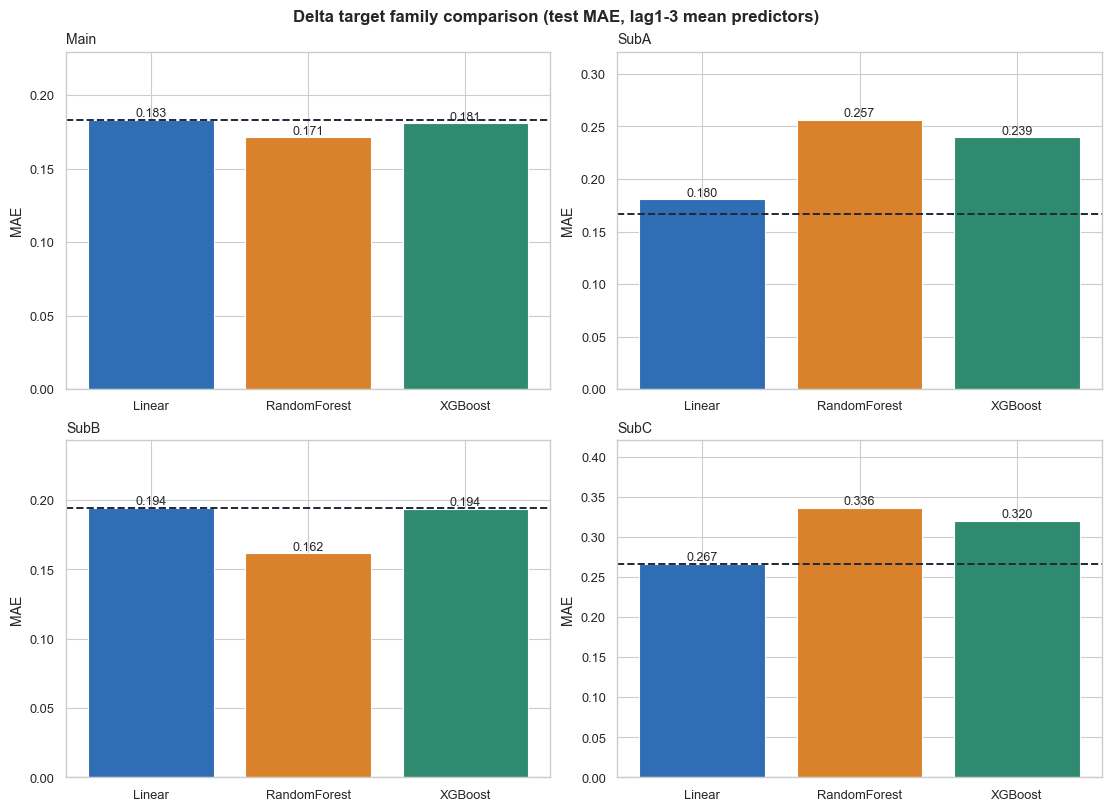

In [4]:
delta = results[results['target_variant'].eq('delta_lag1')].copy()
display(delta[[
    'panel_id', 'lag_suffix', 'family', 'best_model', 'validation_mae', 'test_mae',
    'test_minus_validation_mae',
    'zero_change_baseline_mae', 'delta_test_mae_vs_zero_change',
    'beats_zero_change_baseline', 'n_test', 'dropped_non_annual_pairs'
]])

if PERSISTENCE_FIGURE_OUTPUT.exists():
    display(Image(filename=str(PERSISTENCE_FIGURE_OUTPUT)))

## Interpretability: Top Predictor Roles

,panel_id,family,model,feature_rank,feature_label,importance_kind,normalized_importance,importance_direction
0,main,RandomForest,rf_n100,1,economic/research scale factor (lag 1-3 mean),tree_feature_importance,0.388387,unsigned_tree_importance
1,main,RandomForest,rf_n100,2,environmental technology RTA (lag 1-3 mean),tree_feature_importance,0.161375,unsigned_tree_importance
2,main,RandomForest,rf_n100,3,renewable energy share (lag 1-3 mean),tree_feature_importance,0.106181,unsigned_tree_importance
3,main,RandomForest,rf_n100,4,FDI net inflows (lag 1-3 mean),tree_feature_importance,0.098477,unsigned_tree_importance
4,main,RandomForest,rf_n100,5,inflation (lag 1-3 mean),tree_feature_importance,0.074226,unsigned_tree_importance
5,main,RandomForest,rf_n100,6,CO2 per capita (lag 1-3 mean),tree_feature_importance,0.066640,unsigned_tree_importance
6,suba,Linear,elastic_net_alpha_0.1_l1_0.5,1,RISE renewable energy (lag 1-3 mean),standardized_coefficient,0.917713,negative_coefficient
7,suba,Linear,elastic_net_alpha_0.1_l1_0.5,2,high-tech exports (lag 1-3 mean),standardized_coefficient,0.082287,positive_coefficient
8,suba,Linear,elastic_net_alpha_0.1_l1_0.5,3,RISE energy efficiency (lag 1-3 mean),standardized_coefficient,0.000000,zero_coefficient
9,subb,RandomForest,rf_n200_d10,1,researchers per million (lag 1-3 mean),tree_feature_importance,0.270543,unsigned_tree_importance


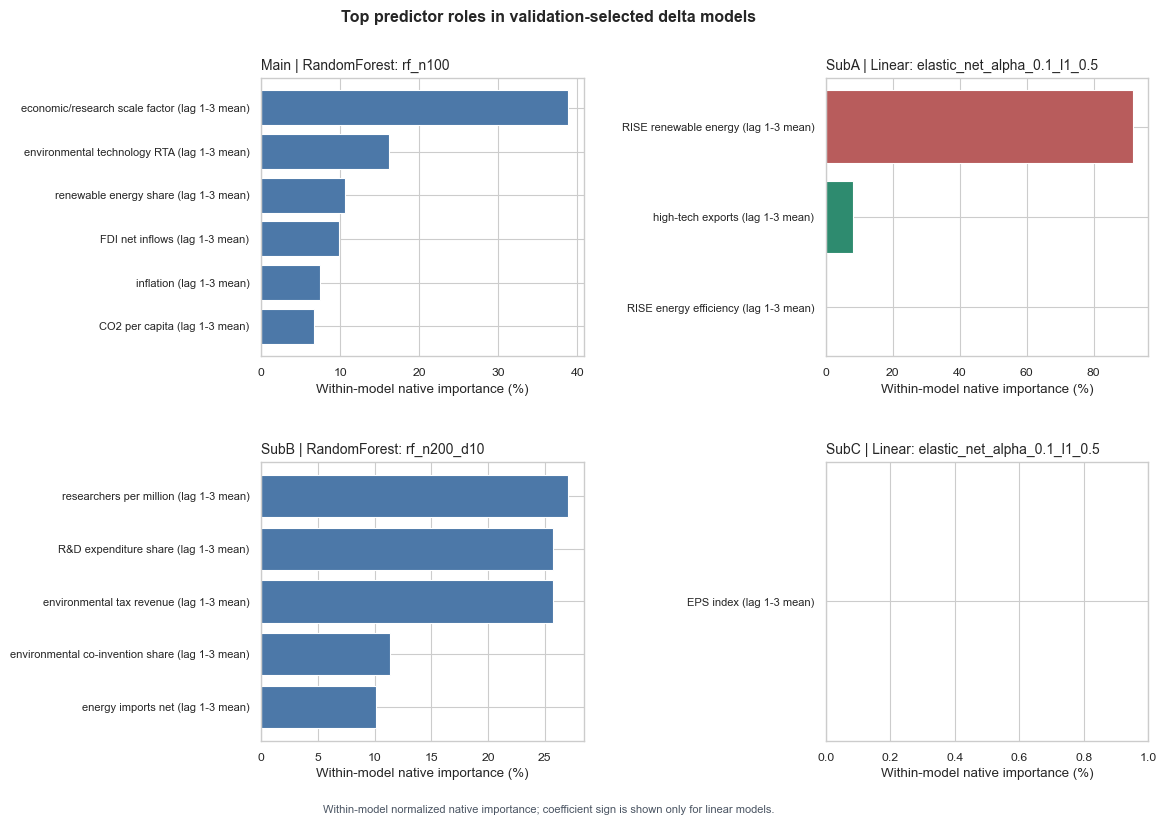

In [5]:
display(top_importance[[
    'panel_id', 'family', 'model', 'feature_rank', 'feature_label',
    'importance_kind', 'normalized_importance', 'importance_direction'
]])

if PERSISTENCE_IMPORTANCE_FIGURE_OUTPUT.exists():
    display(Image(filename=str(PERSISTENCE_IMPORTANCE_FIGURE_OUTPUT)))

## Robustness Task: Log-Ratio Target

In [6]:
log_ratio = results[results['target_variant'].eq('log_ratio_lag1')].copy()
display(log_ratio[[
    'panel_id', 'lag_suffix', 'family', 'best_model', 'validation_mae', 'test_mae',
    'test_minus_validation_mae',
    'zero_change_baseline_mae', 'delta_test_mae_vs_zero_change',
    'beats_zero_change_baseline', 'n_test', 'dropped_non_annual_pairs',
    'dropped_nonpositive_pairs'
]])

,panel_id,lag_suffix,family,best_model,validation_mae,test_mae,test_minus_validation_mae,zero_change_baseline_mae,delta_test_mae_vs_zero_change,beats_zero_change_baseline,n_test,dropped_non_annual_pairs,dropped_nonpositive_pairs
24,main,lag1_3_mean,Linear,elastic_net_alpha_0.1_l1_0.8,0.419043,0.446055,0.027011,0.446430,-0.000375,True,269,264,0
25,main,lag1_3_mean,RandomForest,rf_n100_d10,0.421922,0.466434,0.044512,0.446430,0.020004,False,269,264,0
26,main,lag1_3_mean,XGBoost,xgb_n100_d3,0.427581,0.459472,0.031891,0.446430,0.013042,False,269,264,0
27,main,lag1,Linear,lasso_alpha_0.1,0.413283,0.446198,0.032914,0.446430,-0.000232,True,269,264,0
28,main,lag1,RandomForest,rf_n100_d10,0.360160,0.443029,0.082869,0.446430,-0.003401,True,269,264,0
29,main,lag1,XGBoost,xgb_n100_d3,0.374846,0.437382,0.062536,0.446430,-0.009048,True,269,264,0
30,suba,lag1_3_mean,Linear,elastic_net_alpha_0.1_l1_0.2,0.452944,0.442847,-0.010097,0.439276,0.003571,False,76,77,0
31,suba,lag1_3_mean,RandomForest,rf_n100_d10,0.469441,0.478271,0.008831,0.439276,0.038995,False,76,77,0
32,suba,lag1_3_mean,XGBoost,xgb_n100_d3,0.470218,0.487934,0.017716,0.439276,0.048657,False,76,77,0
33,suba,lag1,Linear,elastic_net_alpha_0.1_l1_0.5,0.452944,0.442847,-0.010097,0.439276,0.003571,False,76,77,0


## Artifact Check

In [7]:
required = [
    PERSISTENCE_OUTPUT,
    PERSISTENCE_SUMMARY_OUTPUT,
    PERSISTENCE_RUN_SUMMARY_OUTPUT,
    PERSISTENCE_IMPORTANCE_OUTPUT,
    PERSISTENCE_TOP_IMPORTANCE_OUTPUT,
    PERSISTENCE_FIGURE_OUTPUT,
    PERSISTENCE_IMPORTANCE_FIGURE_OUTPUT,
]
pd.DataFrame({'artifact': [str(path.relative_to(PROJECT_ROOT)) for path in required], 'exists': [path.exists() for path in required]})

,artifact,exists
0,3_models/outputs/persistence_adjusted_model_fa...,True
1,3_models/outputs/persistence_adjusted_model_fa...,True
2,3_models/outputs/persistence_adjusted_run_summ...,True
3,3_models/outputs/persistence_adjusted_native_i...,True
4,3_models/outputs/persistence_adjusted_top_inte...,True
5,4_analysis/figures/paper/fig12_persistence_adj...,True
6,4_analysis/figures/paper/fig13_persistence_adj...,True
